## Preliminary Raw Data Analysis

In [621]:
# Getting bird's eye view of data from excel file
# Total observations :5000
# Total Features : 13  Target: Personal Loan (0 or 1)
#
# ID                                             : Values between 1 to 1000
# Age        (Customer's age in completed years) :    values are between 23 to 67
# Experience (#years of professional experience):    -3 to 43 [How is negative experience possible?]
# Income     (Annual income of the customer ($000)) : 8 to 224
# Zip code   (Home Address ZIP code.):                9307 to 96651 [Except 9307 all zip codes are 5 digits. 
#                                                     Is 9307 invalid zipcode?]
# Family     (Family size of the customer):           1 to 4
# CCAvg      (Avg. spending on credit cards per month ($000)): 0 to 10
# Education(Education Level. 1: Undergrad; 2: Graduate; 3: Advanced/Professional): 1 to 3
# Mortgage(Value of house mortgage if any. ($000)) 0 to 635
# Personal Loan(Did this customer accept the personal loan offered in the last campaign?) 0 and 1
# Securities account(Does the customer have a securities account with the bank?)  0 and 1
# CD account(Does the customer have a certificate of deposit (CD) account with the bank?)  0 and 1
# Online account(Does the customer use internet banking facilities?)  0 and 1 [What is the significance of this?]
# CreditCard (Does the customer use a credit card issued by UniversalBank?) 0 and 1 [What is the significance of this

# Age to Mortgage represent personal profile of customer
#Personal Loan, Securities account, CD account , Online account and Credit Card represents banking behaviour /relationship 
#of customer

In [622]:
#A securities account sometimes known as a brokerage account is an account that holds financial assets such as
#ecurities on behalf of an investor with a bank, broker or custodian. Investors and traders typically have
#a securities account with the broker or bank they use to buy and sell securities.

#certificate of deposit, or CD, is a type of federally insured savings account that has a fixed interest
#rate and fixed date of withdrawal, known as the maturity date. CDs also typically don't have monthly fees.

## OBJECTIVE

In [623]:
#This case is about a bank (Thera Bank) which has a growing customer base. Majority of these customers are 
#liability customers (depositors) with varying size of deposits. The number of customers who are also borrowers
#(asset customers) is quite small, and the bank is interested in expanding this base rapidly to bring in more loan
#business and in the process, earn more through the interest on loans. In particular, the management wants to
#explore ways of converting its liability customers to personal loan customers (while retaining them as depositors)
#A campaign that the bank ran last year for liability customers showed a healthy conversion rate of over 9% success.
#This has encouraged the retail marketing department to devise campaigns with better target marketing to increase
#the success ratio with minimal budget.

#The management wants to explore ways of converting its liability customers to personal loan customers 
#(while retaining them as depositors).
#A campaign that the bank ran last year for liability customers showed a healthy conversion rate of over 9% success. 
#Retail marketing department wants to devise campaigns with better target marketing to increase the success
#ratio with minimal budget.

#The department wants to build a model that will help them identify the potential customers who have higher
#probability of purchasing the loan. This will increase the success ratio while at the same time reduce
#the cost of the campaign.


## Data Loading

In [624]:
#All imports will go here
import pandas as pd  
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import metrics
from scipy.stats import zscore
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_score
# importing ploting libraries
import matplotlib.pyplot as plt  
%matplotlib inline
#from sklearn.metrics import roc_curve, auc
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, auc,roc_curve

In [625]:
#Read the csv file in a dataframe for analysis
TheraBank_df = pd.read_csv("Bank_Personal_Loan_Modelling-1.csv")

TheraBank_df.shape
#5000 rows and 14 columns. Matches with our analysis of csv file

(5000, 14)

## Exploratory Data Analysis

In [626]:
TheraBank_df.info()
#All columns are numeric

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
ID                    5000 non-null int64
Age                   5000 non-null int64
Experience            5000 non-null int64
Income                5000 non-null int64
ZIP Code              5000 non-null int64
Family                5000 non-null int64
CCAvg                 5000 non-null float64
Education             5000 non-null int64
Mortgage              5000 non-null int64
Personal Loan         5000 non-null int64
Securities Account    5000 non-null int64
CD Account            5000 non-null int64
Online                5000 non-null int64
CreditCard            5000 non-null int64
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


In [627]:
#Get count of unique Ids
TheraBank_df.ID.nunique(dropna=False)
#Total records are 5000 and unique IDS are printed as 50000
# All Ids are unique so all observations represent valid customer Ids and there are no duplications

5000

In [628]:
# For categorical and for numeric values
#Checking presence of missing values
print(TheraBank_df.isna().sum())

#As seen here, there are no missing values in any column

ID                    0
Age                   0
Experience            0
Income                0
ZIP Code              0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal Loan         0
Securities Account    0
CD Account            0
Online                0
CreditCard            0
dtype: int64


In [629]:
#Steps and Tasks 3d.
#5 point summary of numerical attributes
TheraBank_df.describe().T
#5 numbers that help in knowing the center, spread and shape are Xsmallest, First Quartile(Q1 25%),Median (Q2 50%), 
# Third Quartile (Q3 75%) and Xlargest . All these numbers can be seen using describe()

,count,mean,std,min,25%,50%,75%,max
ID,5000.0,2500.500000,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
Age,5000.0,45.338400,11.463166,23.0,35.00,45.0,55.00,67.0
Experience,5000.0,20.104600,11.467954,-3.0,10.00,20.0,30.00,43.0
Income,5000.0,73.774200,46.033729,8.0,39.00,64.0,98.00,224.0
ZIP Code,5000.0,93152.503000,2121.852197,9307.0,91911.00,93437.0,94608.00,96651.0
Family,5000.0,2.396400,1.147663,1.0,1.00,2.0,3.00,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.70,1.5,2.50,10.0
Education,5000.0,1.881000,0.839869,1.0,1.00,2.0,3.00,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.00,0.0,101.00,635.0
Personal Loan,5000.0,0.096000,0.294621,0.0,0.00,0.0,0.00,1.0


In [630]:
#ID and Online donot have much significance in our analysis. We have already found out that all IDs are unique. Online
#seems to be of not much significance. There should be no direct impact

In [631]:
# Inferences:
# Age ranges between 23 and 67 with mean age of 45. The distribution is normal with no skew
#
# Experience ranges between -3 to 43 with average experience of 20 years. There is no skew in the distribution. However, -3 
# seemd to be invalid data 
#
#  Income is between 8000$ to 2,24,000$ with average income of 73774$ and median income of 64000$. 
# There is rightt skew as mean > median
#
# Zip code is between 9307 to 96651. Zip code we need to check areawise analysis of data. Zip code of 9307 appears invalid
#
# Family members count varies between 1 to 4 with median family size of 2. Mean is greater than median indicating right skew
#
# CCAvg average spending per month on credit card ranges between 0$ to 10000$. Median spending is 1500$ and mean spending is
# 1937$. Right skew in distribution
#
# Education is between 1 to 3 with median education of 2
#
# Mortgage is between 0 to 635000$ with median of 0$ and mean of 101713$ . Mean >> Median indicating extreme skew. 
# Median of 0 needs investigation
#
# Personal Loan, Securities account, CD account, online and CrediCard have yes no entries as 1 and 0. Need to check 
# their counts

### ID Analysis

In [632]:
#ID columns was used to check uniqueness. It has no significance in further model building and analysis so we can drop it 
#before proceeding with further analysis

In [633]:
TheraBank_df.drop(axis=0, columns =['ID'], inplace=True, errors='ignore')


In [634]:
#Check if ID is removed
TheraBank_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
Age                   5000 non-null int64
Experience            5000 non-null int64
Income                5000 non-null int64
ZIP Code              5000 non-null int64
Family                5000 non-null int64
CCAvg                 5000 non-null float64
Education             5000 non-null int64
Mortgage              5000 non-null int64
Personal Loan         5000 non-null int64
Securities Account    5000 non-null int64
CD Account            5000 non-null int64
Online                5000 non-null int64
CreditCard            5000 non-null int64
dtypes: float64(1), int64(12)
memory usage: 507.9 KB


### Age Analysis

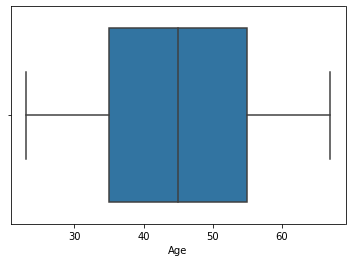

In [635]:
#Maximum distribution is between 35 to 55 with median age of 45
#No outliers
sns.boxplot(x=TheraBank_df['Age'])

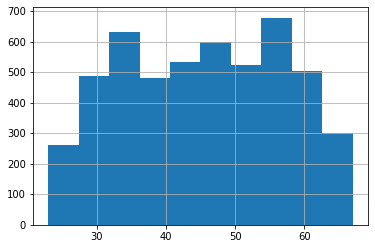

In [636]:
TheraBank_df['Age'].hist()
#Maximum existing customers of bank are in the age group of 53 to 58(approx 670), followed by 32 to 37 (approx 620)
#followed by 46 to 49 (approx 600)  

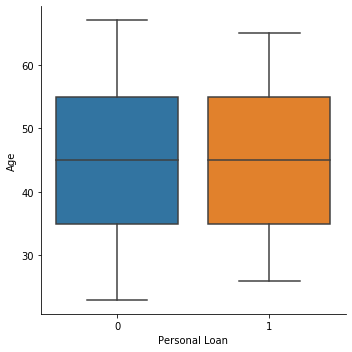

In [637]:
sns.catplot(x="Personal Loan", y="Age",kind="box", data=TheraBank_df);
# There is no difference in distribution of age for person who take loan and who dont take. Median age is 45 and
# between 35 to 55 years of age maximum density. However, minimum age is 15 and maximum age is 65 for case who have
# taken personal loan

In [638]:
#Age does not appear to be strong predictor

### EXPERIENCE ANALYSIS

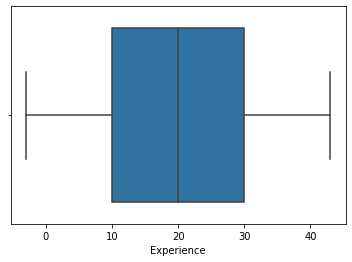

In [639]:
sns.boxplot(x=TheraBank_df['Experience'])
#No outliers exist. Maximum distribution between 10 to 30 years of experience
# There are no outliers. Appears normal distribution. Maximum distribution between 10 to 30 years of experience with median
# experience of 20 years. 
#No outliers exist

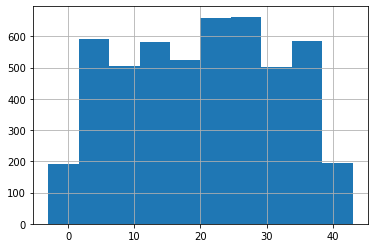

In [640]:
#Experience has normal distribution except that few datapoints have experience<0
TheraBank_df['Experience'].hist()
#Almost equal number of data points for experience between 2 to 38. Less than 2  years(about 190 data points) and 
#between  38 to 45(about 190 data points are there) 

#### EXPERIENCE-INVALID DATA REMOVAL

In [641]:
pd.crosstab([TheraBank_df[TheraBank_df['Experience']<=0]['Experience']], TheraBank_df['Personal Loan'], margins=False)

Personal Loan,0,1
Experience,,
-3,4,0
-2,15,0
-1,33,0
0,59,7


In [642]:
#52 have less than 0 experience and none of these have taken loan. This experience is invalid (doesnt make sense)
#It represnts about 1% of total data and also doesnt belong to Class of Interest(Personal Loan=1) so we can delete is 
#which could lead to a little downsampling. 
#Cusomers with 0 experience is taking loans (though such cusomers should not be given loan) ,we are not going to delete
#these as there are few individul who are taking loan [class of interest] 
TheraBank_df.drop(TheraBank_df[TheraBank_df['Experience'] < 0].index, inplace = True, errors='ignore')
 

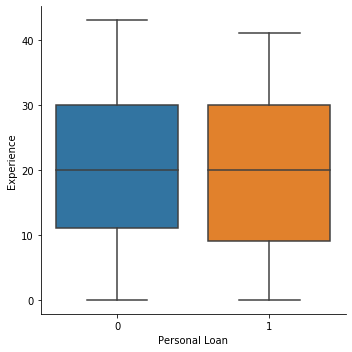

In [643]:
sns.catplot(x="Personal Loan", y="Experience",kind="box", data=TheraBank_df);


In [644]:
#Experience is not showing any difference vis a vis person who have taken personal loan and those who have not

### INCOME ANALYSIS

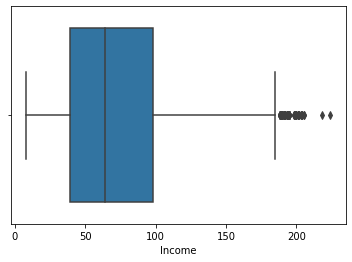

In [645]:
sns.boxplot(x=TheraBank_df['Income'])
#Many outliers towards higher income. The outliers have income higher than 185000$. We need to see if any
# of these have taken personal loan

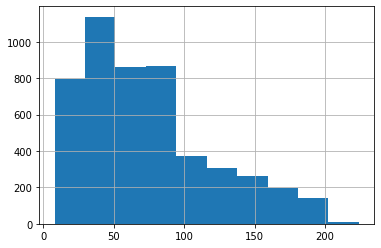

In [646]:
TheraBank_df['Income'].hist()
#Maximum customers of bank are in 30,000  to 50,000 $ income group. From 95,000 to 2,70,000 $ income group
#the number of customers are relatively lesser than lower incomes. Maximum density of customers is between
# 10000$ to 90000 $

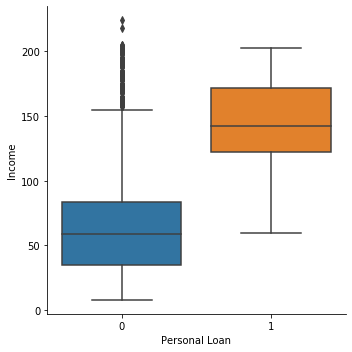

In [647]:
sns.catplot(x="Personal Loan", y="Income",kind="box", data=TheraBank_df);
# Maximum Personl loan have been taken by individuals between 1,20,000 to 1,70,000$ income. The personal loan has been 
# taken by persona with income as low as 60000$ and as max as 165000$
#All the outliers belong to group which which hasnot taken personal loan

### ZIP CODE ANALYSIS

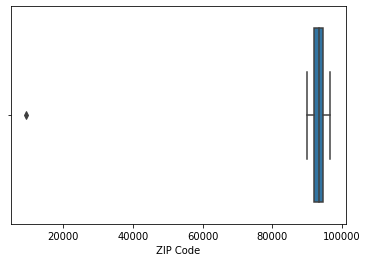

In [648]:
#ZIP Code
sns.boxplot(x=TheraBank_df['ZIP Code'])

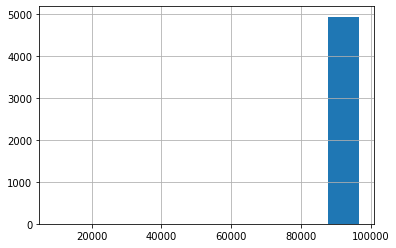

In [649]:
TheraBank_df['ZIP Code'].hist()

#### ZIPCODE-INVALID DATA REMOVAL

In [650]:
#ZIP code of 9307 is an outlier. It needs to be investigated if it has PersonalLoan=1 data. Then we cannot
#afford to lose it as we already have limited data on it
TheraBank_df[TheraBank_df['ZIP Code']== 9307]

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
384,51,25,21,9307,4,0.6,3,0,0,0,0,1,1


In [651]:
#9307 is invalid ZIP code  so we can remove the row [Imputation of ZIP code wit mean median Mode doesnot make sense]
TheraBank_df.drop(TheraBank_df[TheraBank_df['ZIP Code'] == 9307].index, inplace = True, errors='ignore') 

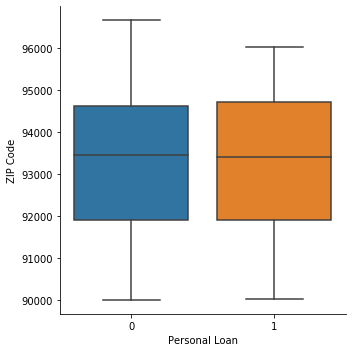

In [652]:
sns.catplot(x="Personal Loan", y="ZIP Code",kind="box", data=TheraBank_df)

In [653]:
#Get count of unique Ids
TheraBank_df["ZIP Code"].nunique(dropna=False)
#Total records are 5000 and there are 467 unique zip codes

466

In [654]:
#TheraBank_df.groupby(["ZIP Code"])[TheraBank_df[TheraBank_df['Personal Loan']==1]['Personal Loan']].value_counts()
#pd.crosstab(TheraBank_df['ZIP Code'], TheraBank_df[TheraBank_df['Personal Loan']==1]['Personal Loan'], margins=False)
#zip_df = TheraBank_df[TheraBank_df.duplicated(['ZIP Code'])][TheraBank_df['Personal Loan']>=1]
#print(zip_df['ZIP Code'][P])
#TheraBank_df.groupby(["ZIP Code"])[TheraBank_df[TheraBank_df['Personal Loan']==1]['Personal Loan']]

### FAMILY ANALYSIS

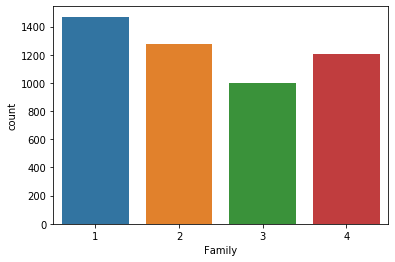

In [655]:
sns.countplot(x=TheraBank_df['Family'])
# Maximum customers(about 1450) have family size of 1, Next comes family size 2 with approximate 1300 customers, 
# Next comes family size of 4 customers with approximate 1220 customers, last comes family size of 3 with approximate
# 1000 customerss

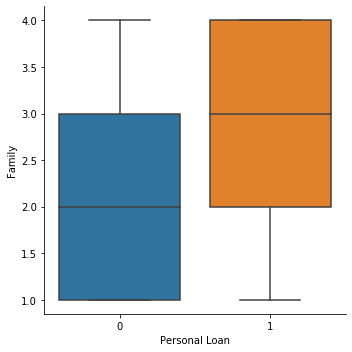

In [656]:
sns.catplot(x="Personal Loan", y="Family",kind="box", data=TheraBank_df);
# all the customers who have taken loan have family size between 2 to 4 and there are some customers who have family size
# between 2 to 3 who have not taken loan (what could be the reason). Between 3 to 4 family size almost all customers have
#taken loan  

### CCAvg Analysis

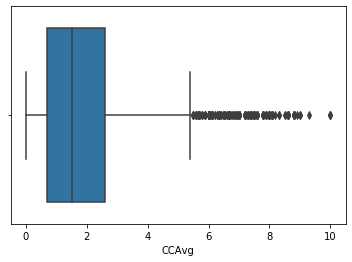

In [657]:
sns.boxplot(x=TheraBank_df['CCAvg'])
# Average Spending per month on credit card ranges between 0$ to 5200$. Maximum density of customers have avg spending between 
# 800$ to 2600$. There are many outliers where spending is more that 5200$

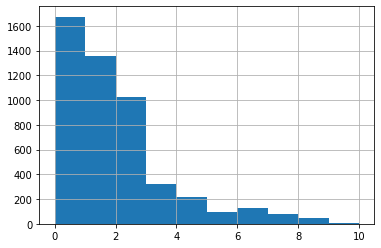

In [658]:
TheraBank_df['CCAvg'].hist()
#Maximum customers (1650 approx have almost 0 average credit card bill. The histogram has right skew with many high
# Credit card bill being outlier. Maximum individuals have credit card bill monthly average of upto 3000$ 
#(Total count of such customers is approx 4000)

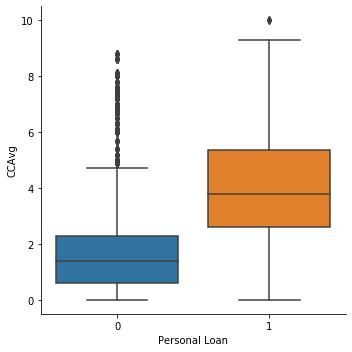

In [659]:
sns.catplot(x="Personal Loan", y="CCAvg",kind="box", data=TheraBank_df)
#Customer with higher average credit card bills have taken personal loan. Though few customers with 0 credit card bill
#have taken loan but maximum customers with monthly average credit card bill between 2600$ and 5500$ have taken loan

### EDUCATION ANALYSIS

In [660]:
#sns.boxplot(x=TheraBank_df['Education'])

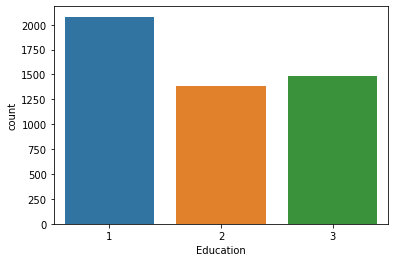

In [661]:
#TheraBank_df['Education'].hist()
sns.countplot(x=TheraBank_df['Education'])
#1: Undergrad; 2: Graduate; 3: Advanced/Professional
# Maximum customers are Undergraduate with count approximately 2120
# Next count is of customers with Advanced/Professional education approximately 1450
# next comes graduates with count of approx 1370 

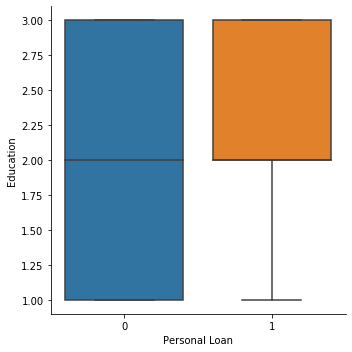

In [662]:
sns.catplot(x="Personal Loan", y="Education",kind="box",data=TheraBank_df)
#Mostly customers with graduate and advanced/professional degree have taken loan though few of them have not taken loan as well
# But no undergraduate has taken loan

In [663]:
(TheraBank_df.groupby(["Education"]))[['Personal Loan']].sum()
#Undergraduates constitute 19% of loan takers
# Graduates constitute 38%
# Advanced degree /professionals constitute 43%

,Personal Loan
Education,
1,93
2,182
3,205


### MORTGAGE ANALYSIS

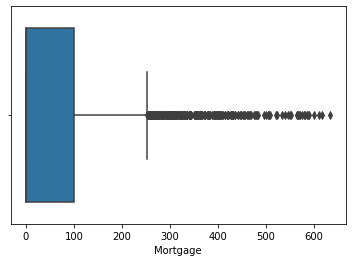

In [664]:
sns.boxplot(x=TheraBank_df['Mortgage'])
#Extreme right skew with high mortgage values higher than 2,70,000 being mostly outliers

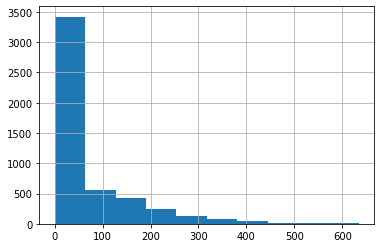

In [665]:
TheraBank_df['Mortgage'].hist()
# Around 3300 customers have house mortgage values of 0 to 60000$ . Total 1700 customers have mrotgage values between
# 61000$ to 6,00,000$Beyond 310000$ value , the customers are mostly outliers

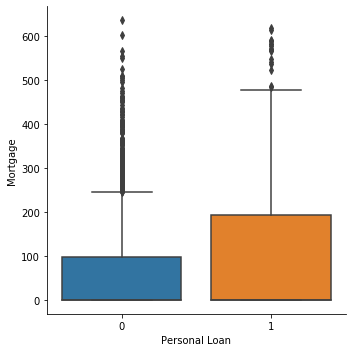

In [666]:
sns.catplot(x="Personal Loan", y="Mortgage",kind="box", data=TheraBank_df);
#Customers who have taken loan have mortgage value between 0 to 2,00,000$

### Securities Account

In [667]:
# Securiies Account analysis
TheraBank_df.groupby("Securities Account").count()
# Only 10% of total customers have approximately securities account

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,CD Account,Online,CreditCard
Securities Account,,,,,,,,,,,,
0,4431,4431,4431,4431,4431,4431,4431,4431,4431,4431,4431,4431
1,516,516,516,516,516,516,516,516,516,516,516,516


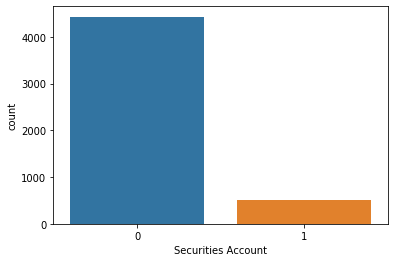

In [668]:
sns.countplot(x=TheraBank_df['Securities Account'])

In [669]:
(TheraBank_df.groupby(["Securities Account"]))[['Personal Loan']].sum()

,Personal Loan
Securities Account,
0,420
1,60


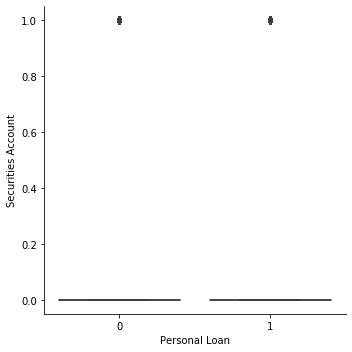

In [670]:
sns.catplot(x="Personal Loan", y="Securities Account",kind="box", data=TheraBank_df)

### CD Account

In [671]:
#sns.boxplot(x=TheraBank_df['CD Account'])

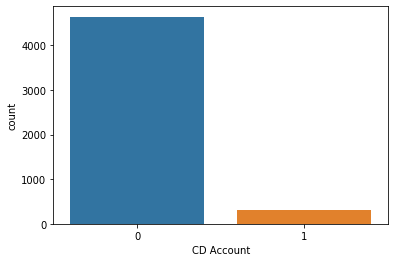

In [672]:
sns.countplot(x=TheraBank_df['CD Account'])
#Very few customers have CD account (nearly 250)

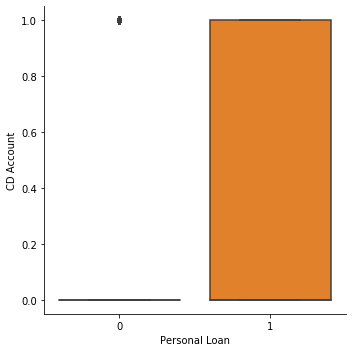

In [673]:
sns.catplot(x="Personal Loan", y="CD Account",kind="box", data=TheraBank_df)
#All customers with CD account have taken personal loan

### ONLINE ACCOUNT ANALYSIS

In [674]:
#Though Online account doesnot seem to be an inportant feature vis a vis customer's willingness or ability to take personal
#loan. Howevr, need to analyse if some relation emerges
TheraBank_df.groupby("Online").count()

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,CreditCard
Online,,,,,,,,,,,,
0,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994
1,2953,2953,2953,2953,2953,2953,2953,2953,2953,2953,2953,2953


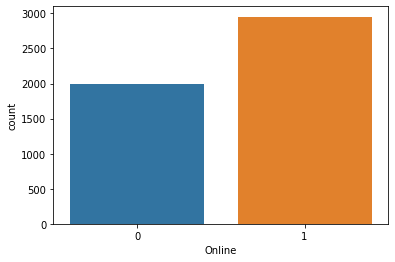

In [675]:
sns.countplot(x=TheraBank_df['Online'])
#approx 2000 have no internet banking facility and 3000 have online(internet access facility) 

In [676]:
(TheraBank_df.groupby(["Online"]))[['Personal Loan']].sum()
# Only 9% of person with no internet banking facility have taken loan [189/2000]
# Only 10% of person with internet banking facility have taken loan [291/3000]

,Personal Loan
Online,
0,189
1,291


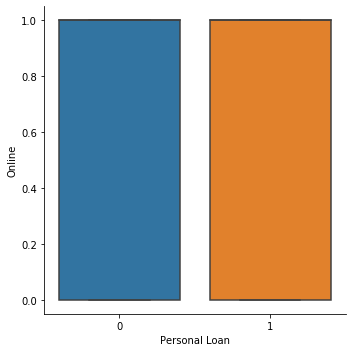

In [677]:
sns.catplot(x="Personal Loan", y="Online",kind="box", data=TheraBank_df)
# No correlation between Online account and personal loan taking by customer

### Credit Card

In [678]:
TheraBank_df.groupby("CreditCard").count()

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online
CreditCard,,,,,,,,,,,,
0,3493,3493,3493,3493,3493,3493,3493,3493,3493,3493,3493,3493
1,1454,1454,1454,1454,1454,1454,1454,1454,1454,1454,1454,1454


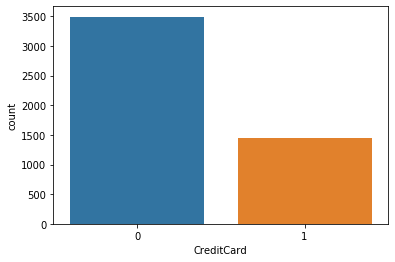

In [679]:
sns.countplot(x=TheraBank_df['CreditCard'])

In [680]:
TheraBank_df.groupby(["CreditCard"])[['Personal Loan']].sum()

,Personal Loan
CreditCard,
0,337
1,143


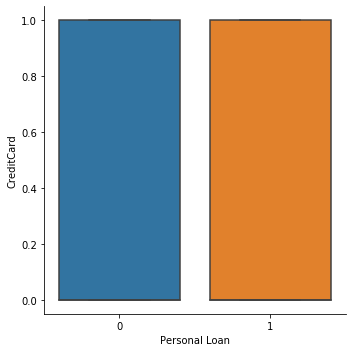

In [681]:
sns.catplot(x="Personal Loan", y="CreditCard",kind="box", data=TheraBank_df)

### Target Class Analysis

In [682]:
# Personal loan analysis vis a vis other numeric attributes have been analysed previously
TheraBank_df.groupby("Personal Loan").count()
#Out of 5000 targeted customers, only 480 took personal loan

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Securities Account,CD Account,Online,CreditCard
Personal Loan,,,,,,,,,,,,
0,4467,4467,4467,4467,4467,4467,4467,4467,4467,4467,4467,4467
1,480,480,480,480,480,480,480,480,480,480,480,480


In [683]:
pd.crosstab([TheraBank_df.CreditCard, TheraBank_df['Securities Account'], TheraBank_df['CD Account'], TheraBank_df['Online']], TheraBank_df['Personal Loan'], margins=False)

Personal Loan                                       0    1
CreditCard Securities Account CD Account Online           
0          0                  0          0       1159  116
                                         1       1664  165
                              1          1          0   13
           1                  0          0        130    9
                                         1        188    0
                              1          0          0    3
                                         1         15   31
1          0                  0          0        469   50
                                         1        653    0
                              1          0          0    4
                                         1         66   72
           1                  0          0         42    0
                              1          0          5    7
                                         1         76   10

In [684]:
# Maximum loan taken by group which doesnot have credit card, Securitie account and CD account

### CORRELATION ANALYSIS

In [685]:
TheraBank_df.corr()

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
Age,1.000000,0.994102,-0.057903,-0.030786,-0.039423,-0.050809,0.046101,-0.015131,-0.014172,0.000529,0.003286,0.013464,0.007347
Experience,0.994102,1.000000,-0.049157,-0.030521,-0.045737,-0.048879,0.018135,-0.013414,-0.014094,-0.000429,0.005472,0.013451,0.008749
Income,-0.057903,-0.049157,1.000000,-0.029092,-0.155393,0.646125,-0.187742,0.206826,0.504224,-0.002407,0.170136,0.014626,-0.004136
ZIP Code,-0.030786,-0.030521,-0.029092,1.000000,0.026903,-0.010623,-0.008152,0.004627,-0.002852,0.001009,0.021879,0.031041,0.023800
Family,-0.039423,-0.045737,-0.155393,0.026903,1.000000,-0.107041,0.063678,-0.020266,0.063194,0.020256,0.015349,0.008235,0.012472
CCAvg,-0.050809,-0.048879,0.646125,-0.010623,-0.107041,1.000000,-0.133765,0.109829,0.369363,0.012425,0.137556,-0.003350,-0.007140
Education,0.046101,0.018135,-0.187742,-0.008152,0.063678,-0.133765,1.000000,-0.032416,0.138454,-0.007417,0.014710,-0.014157,-0.013028
Mortgage,-0.015131,-0.013414,0.206826,0.004627,-0.020266,0.109829,-0.032416,1.000000,0.142291,-0.003756,0.089343,-0.006662,-0.006737
Personal Loan,-0.014172,-0.014094,0.504224,-0.002852,0.063194,0.369363,0.138454,0.142291,1.000000,0.022194,0.315758,0.006230,0.002879
Securities Account,0.000529,-0.000429,-0.002407,0.001009,0.020256,0.012425,-0.007417,-0.003756,0.022194,1.000000,0.319044,0.016159,-0.016928


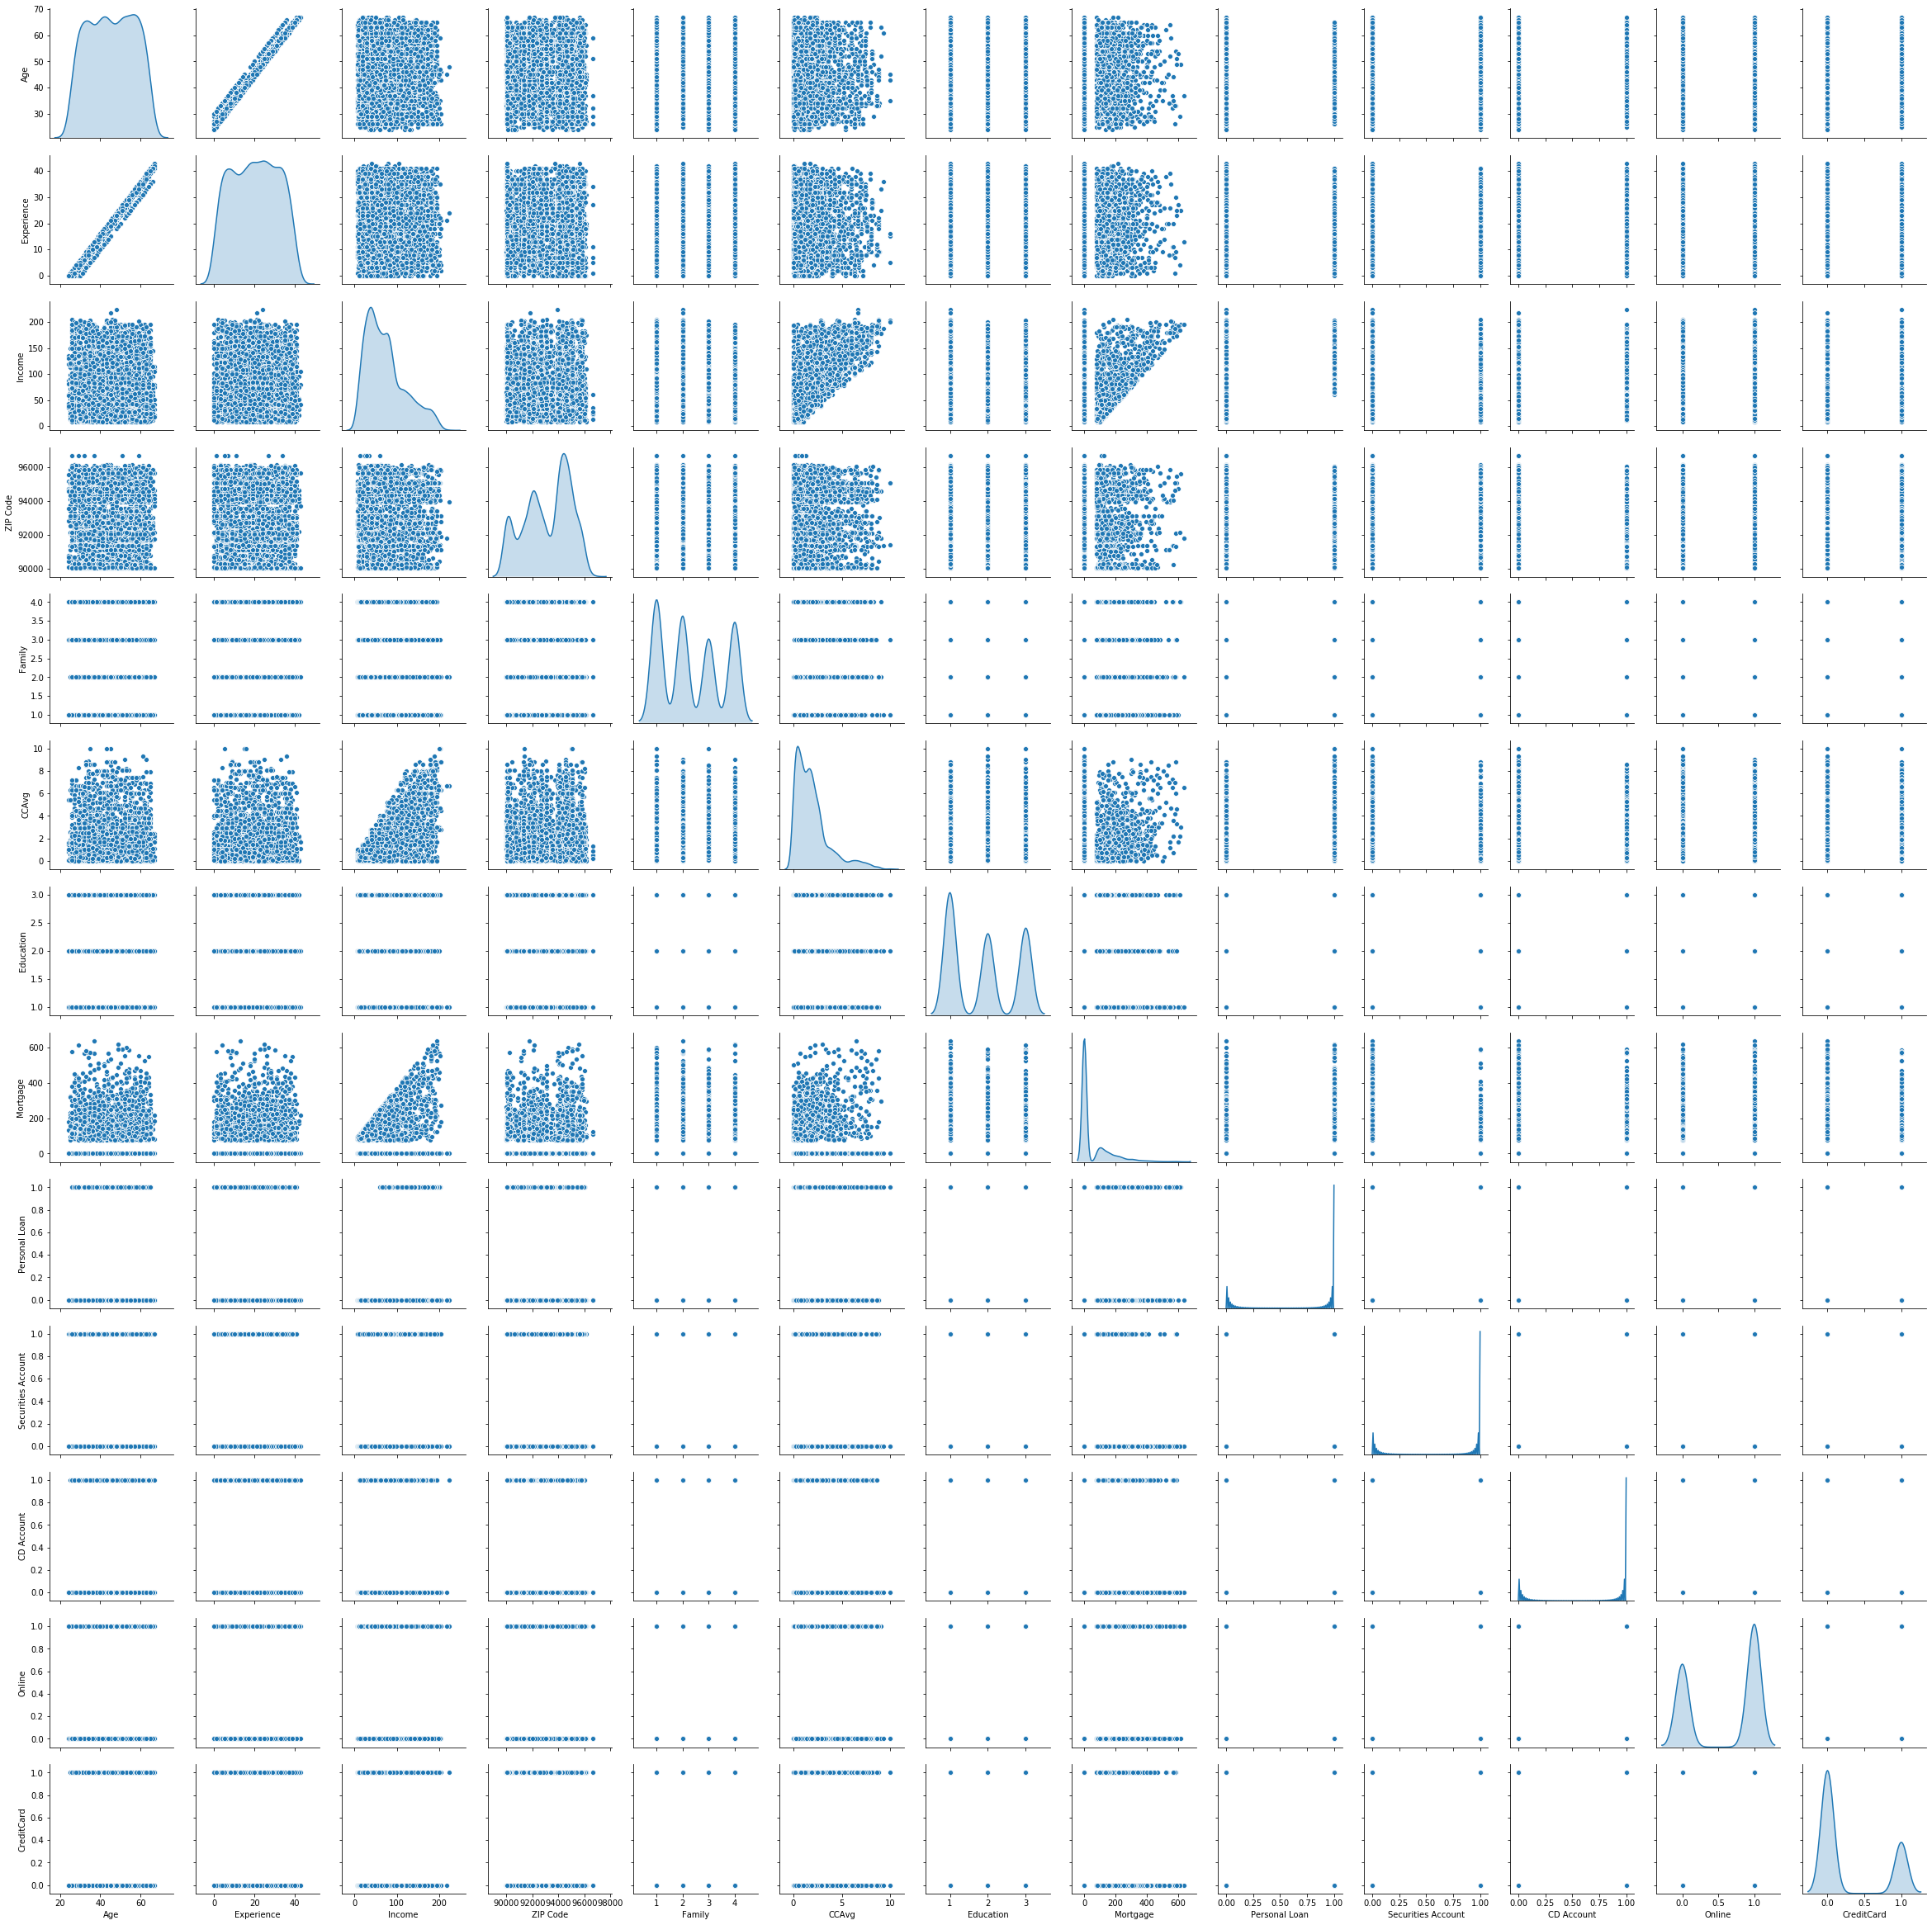

In [686]:
#Check correlation between dependent and independent variables
sns.pairplot(TheraBank_df, diag_kind='kde')

In [687]:
#CCAvg :
#Income
# Age and Experience have perfectly linear relationship [very strong correlation] but they have vry weak relationship with Target
# Age and Experience dont seem to be good predictors
# Family showing 4 peaks corresponding to 1 , 2 ,3 and 4 family members. Height of peaks as 1->2->4->3 (individuals have more representation
# in the data . Do singles hold more bank accounts)
# Zip code

In [688]:
#Of 5000, only 480 customers have personal loan which is meagre 9.6%. Though the percentage is small we need to observe the
#characteristics of these users. Can we extrapolate the behaviour of population based on this?

#Since class of interest is very small proportion so this is a case of Imbalanced data set. Classification would be more
#biased towards majority class 

## Delete Poor Predictors

In [689]:
# Not making much Impact on performance so not deleting
#TheraBank_df.drop(axis=0, columns =['Age'], inplace=True, errors='ignore')
#TheraBank_df.drop(axis=0, columns =['Experience'], inplace=True, errors='ignore')
#TheraBank_df.drop(axis=0, columns = ['Online Account'], inplace=True, errors='ignore')

## Data Preparation

In [690]:
#Separate features and Target
y = TheraBank_df[['Personal Loan']]
X= TheraBank_df.drop('Personal Loan', axis= 1, errors='ignore')

## Data Normalization

In [691]:
#1. Normalize X : from scipy.stats import zscore
X_std = X.apply(zscore)

## Data Splitting

In [692]:
#Train test split in 70:30 ratio
X_train, X_test, y_train, y_test = train_test_split(X_std, y, test_size=0.30, random_state=7)
print("X_train ",X_train.shape," y_train ",y_train.shape)
print("X_test ",X_train.shape," y_test ",y_test.shape)

X_train  (3462, 12)  y_train  (3462, 1)
X_test  (3462, 12)  y_test  (1485, 1)


## MODELLING

### LOGISTIC REGRESSION MODEL

#### Logistic Regression Base and Optimized - With Performance Parameters

In [693]:
def modelLogisticPerformanceAnalysis(X_train, X_test, y_train, y_test):  
    model = LogisticRegression()
    model.fit(X_train, y_train)
    
    ### Base Model Unoptimized probability threshold based performance numbers
    
    # Train accuracy numbers
    y_predictProb = model.predict_proba(X_train)
    # Retrieving probability for class of interest which is 1 (Personal loan taken)   
    trainPreds = np.where(y_predictProb[:,1] > 0.5, 1, 0)
    trainAccuracy = accuracy_score(y_train, trainPreds)
    trainRecall = recall_score(y_train, trainPreds)
    trainPrecision = precision_score(y_train, trainPreds)
    trainF1score = f1_score(y_train, trainPreds)
    trainResults=[X_train.shape[0], 0.5, trainAccuracy, trainRecall, trainPrecision, trainF1score]
    
    # Test accuracy numbers
    testPreds = np.where(model.predict_proba(X_test)[:,1] > 0.5, 1, 0)
    testAccuracy = accuracy_score(y_test, testPreds)
    testRecall = recall_score(y_test, testPreds)
    testPrecision = precision_score(y_test, testPreds)
    testF1score = f1_score(y_test, testPreds)
    testResults=[X_test.shape[0], 0.5, testAccuracy, testRecall, testPrecision, testF1score]
    
    #### Optimize probability threshold and calculate performance numbers
    #y_predictProb = model.predict_proba(X_train)
    fpr, tpr, thresholds = roc_curve(y_train, y_predictProb[::,1])
    
    optimalF1 = 0
    optimalTh = 0
    
    #Loop and 
    for th in thresholds:
        preds = np.where(model.predict_proba(X_train)[:,1] > th, 1, 0)
        f1Score = f1_score(y_train, preds)
        
        if(optimalF1 < f1Score):
            optimalF1 = f1Score
            optimalTh = th

    # Optimal probability threshold based train accuracy numbers
    trainPreds = np.where(model.predict_proba(X_train)[:,1] > optimalTh, 1, 0)
    trainAccuracy = accuracy_score(y_train, trainPreds)
    trainRecall = recall_score(y_train, trainPreds)
    trainPrecision = precision_score(y_train, trainPreds)
    trainF1score = f1_score(y_train, trainPreds)
    optimalTrainResults=[X_train.shape[0], optimalTh, trainAccuracy, trainRecall, trainPrecision, trainF1score]
    
    # Optimal probability threshold based test accuracy numbers
    testPreds = np.where(model.predict_proba(X_test)[:,1] > optimalTh, 1, 0)
    testAccuracy = accuracy_score(y_test, testPreds)
    testRecall = recall_score(y_test, testPreds)
    testPrecision = precision_score(y_test, testPreds)
    testF1score = f1_score(y_test, testPreds)
    optimalTestResults=[X_test.shape[0], optimalTh, testAccuracy, testRecall, testPrecision, testF1score]
    
    # Concatenate Train and Test results to resultsDf
    resultsDf = pd.DataFrame( index=["dataSize", "optimalTh", "accuracy", "recall", "precision", "f1_score"])
    resultsDf['unOptimalTrainResults'] = trainResults
    resultsDf['unOptimalTestResults'] = testResults
    resultsDf['optimalTrainResults'] = optimalTrainResults
    resultsDf['optimalTestResults'] = optimalTestResults
    
    #Confusion Matrix
    print("Train Confusion Matrix is :\n",metrics.confusion_matrix(y_train, trainPreds))
    print("Test Confusion Matrix is :\n",metrics.confusion_matrix(y_test, testPreds))
    
    return resultsDf.round(2)

In [694]:
modelLogisticPerformanceAnalysis(X_train, X_test, y_train, y_test )

C:\Users\DELL\Anaconda3\lib\site-packages\sklearn\linear_model\logistic.py:432: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)
C:\Users\DELL\Anaconda3\lib\site-packages\sklearn\utils\validation.py:724: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\DELL\Anaconda3\lib\site-packages\sklearn\metrics\classification.py:1437: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no predicted samples.
  'precision', 'predicted', average, warn_for)
C:\Users\DELL\Anaconda3\lib\site-packages\sklearn\metrics\classification.py:1437: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no predicted samples.
  'precision', 'predicted', average, warn_for)


Train Confusion Matrix is :
 [[3064   73]
 [  96  229]]
Test Confusion Matrix is :
 [[1308   22]
 [  54  101]]


,unOptimalTrainResults,unOptimalTestResults,optimalTrainResults,optimalTestResults
dataSize,3462.00,1485.00,3462.00,1485.00
optimalTh,0.50,0.50,0.37,0.37
accuracy,0.95,0.95,0.95,0.95
recall,0.63,0.59,0.70,0.65
precision,0.83,0.87,0.76,0.82
f1_score,0.71,0.70,0.73,0.73


### KNN Model

In [695]:
#1. Normalize train data and test data : from scipy.stats import zscore [DONE THIS STEP ABOVE]
#2. Build KNN algorithm with default number of neighbors : from sklearn.neighbors import KNeighborsClassifier
#3. Calculate performance of KNN on train data and test data : from sklearn.metrics import accuracy_score
#4. Find the optimal number of neighbors our KNN model
#5. Again calculate performance of KNN with optimal of number of neights(found in Step4) and 
#compare train and test performances with Step 2 model

In [696]:
def modelKNNPerformanceAnalysis(X_train, X_test, y_train, y_test):
    #Default Base KNN MOdel with number of neighbours as 5
    KNC_model = KNeighborsClassifier()
    KNC_model.fit(X_train, y_train)
    
    ### Unoptimized probability threshold based performance numbers
    # Train accuracy numbers
    #trainPreds = np.where(model.predict_proba(X_train)[:,1] > 0.5, 1, 0)
    trainPreds = KNC_model.predict(X_train)
    trainAccuracy = accuracy_score(y_train, trainPreds)
    trainRecall = recall_score(y_train, trainPreds)
    trainPrecision = precision_score(y_train, trainPreds)
    trainF1score = f1_score(y_train, trainPreds)
    trainResults=[X_train.shape[0], trainAccuracy, trainRecall, trainPrecision, trainF1score]
    
    # Test accuracy numbers
    #testPreds = np.where(model.predict_proba(X_test)[:,1] > 0.5, 1, 0)
    testPreds = KNC_model.predict(X_test)
    testAccuracy = accuracy_score(y_test, testPreds)
    testRecall = recall_score(y_test, testPreds)
    testPrecision = precision_score(y_test, testPreds)
    testF1score = f1_score(y_test, testPreds)
    testResults=[X_test.shape[0], testAccuracy, testRecall, testPrecision, testF1score]
    
    #Optimal K calculation    
    #Maximum K value calculation 
    maximumK = (int)(np.sqrt(X_train.shape[0])) #square root of number of observations
    print(maximumK)
    
    #Taking maximumK+1 values if maximumK is even, We should take odd k values
    if (maximumK%2 == 0):
        klist = list(range(1,maximumK+1))
    else:
        klist = list(range(1,maximumK))

    #Taking odd k values
    kvalues = list(filter(lambda x: x%2 != 0, klist))
    #print(kvalues)

    # empty list that will hold cv scores
    cv_scores = []

    # perform 10-fold cross validation
    for k in kvalues:
        knn = KNeighborsClassifier(n_neighbors=k)
        scores = cross_val_score(knn, X_train, y_train, cv=10, scoring='accuracy')
        cv_scores.append(scores.mean())
    
    # determining best k
    #optimal_k = neighbors[misError.index(min(misError))] #commented
    optimal_k = kvalues[cv_scores.index(max(cv_scores))]
    print("The optimal number of neighbors is %d" % optimal_k)#OPTIMAL K IS 3
    
    #fitting data for optimal k
    KNNOptimal = KNeighborsClassifier(n_neighbors=optimal_k)
    KNNOptimal.fit(X_train, y_train)
    
    # Optimal train accuracy numbers
    trainPreds = KNNOptimal.predict(X_train)
    trainAccuracy = accuracy_score(y_train, trainPreds)
    trainRecall = recall_score(y_train, trainPreds)
    trainPrecision = precision_score(y_train, trainPreds)
    trainF1score = f1_score(y_train, trainPreds)
    optimalTrainResults=[X_train.shape[0], trainAccuracy, trainRecall, trainPrecision, trainF1score]
    
    # Optimal test accuracy numbers
    testPreds = KNNOptimal.predict(X_test)
    testAccuracy = accuracy_score(y_test, testPreds)
    testRecall = recall_score(y_test, testPreds)
    testPrecision = precision_score(y_test, testPreds)
    testF1score = f1_score(y_test, testPreds)
    optimalTestResults=[X_test.shape[0], testAccuracy, testRecall, testPrecision, testF1score]
    
    # Concatenate Train and Test results to resultsDf
    resultsDf = pd.DataFrame( index=["dataSize", "accuracy", "recall", "precision", "f1_score"])
    resultsDf['unOptimalTrainResults'] = trainResults
    resultsDf['unOptimalTestResults'] = testResults
    resultsDf['optimalTrainResults'] = optimalTrainResults
    resultsDf['optimalTestResults'] = optimalTestResults
    
    #Confusion Matrix
    print("Train Confusion Matrix is :\n",metrics.confusion_matrix(y_train, trainPreds))
    print("Test Confusion Matrix is :\n",metrics.confusion_matrix(y_test, testPreds))
    
    return resultsDf.round(2)

In [697]:
modelKNNPerformanceAnalysis(X_train, X_test, y_train, y_test)

C:\Users\DELL\Anaconda3\lib\site-packages\ipykernel_launcher.py:4: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  after removing the cwd from sys.path.


58


C:\Users\DELL\Anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:514: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
C:\Users\DELL\Anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:514: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
C:\Users\DELL\Anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:514: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
C:\Users\DELL\Anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:514: DataConversionWarning: A column-vector y was

C:\Users\DELL\Anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:514: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
C:\Users\DELL\Anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:514: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
C:\Users\DELL\Anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:514: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
C:\Users\DELL\Anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:514: DataConversionWarning: A column-vector y was

C:\Users\DELL\Anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:514: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
C:\Users\DELL\Anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:514: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
C:\Users\DELL\Anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:514: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
C:\Users\DELL\Anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:514: DataConversionWarning: A column-vector y was

...

C:\Users\DELL\Anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:514: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
C:\Users\DELL\Anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:514: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
C:\Users\DELL\Anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:514: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
C:\Users\DELL\Anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:514: DataConversionWarning: A column-vector y was

The optimal number of neighbors is 3


C:\Users\DELL\Anaconda3\lib\site-packages\ipykernel_launcher.py:56: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().


Train Confusion Matrix is :
 [[3129    8]
 [  84  241]]
Test Confusion Matrix is :
 [[1326    4]
 [  68   87]]


,unOptimalTrainResults,unOptimalTestResults,optimalTrainResults,optimalTestResults
dataSize,3462.00,1485.00,3462.00,1485.00
accuracy,0.97,0.95,0.97,0.95
recall,0.67,0.52,0.74,0.56
precision,0.97,0.99,0.97,0.96
f1_score,0.79,0.68,0.84,0.71


In [698]:
#Train confusion matrix
#confusion_matrix(y_train, KNN.predict(X_train))

### Naive Bayes Model

In [699]:
def gaussianPerformanceAnalysis(X_train, X_test, y_train, y_test):
    model = GaussianNB()
    model.fit(X_train, y_train)

    ### Unoptimized probability threshold based performance numbers
    # Train accuracy numbers
    trainPreds = np.where(model.predict_proba(X_train)[:,1] > 0.5, 1, 0)
    trainAccuracy = accuracy_score(y_train, trainPreds)
    trainRecall = recall_score(y_train, trainPreds)
    trainPrecision = precision_score(y_train, trainPreds)
    trainF1score = f1_score(y_train, trainPreds)
    trainResults=[X_train.shape[0], 0.5, trainAccuracy, trainRecall, trainPrecision, trainF1score]
    
    # Test accuracy numbers
    testPreds = np.where(model.predict_proba(X_test)[:,1] > 0.5, 1, 0)
    testAccuracy = accuracy_score(y_test, testPreds)
    testRecall = recall_score(y_test, testPreds)
    testPrecision = precision_score(y_test, testPreds)
    testF1score = f1_score(y_test, testPreds)
    testResults=[X_test.shape[0], 0.5, testAccuracy, testRecall, testPrecision, testF1score]
    
    #### Optimize probability threshold and calculate performance numbers
    y_predictProb = model.predict_proba(X_train)
    fpr, tpr, thresholds = roc_curve(y_train, y_predictProb[::,1])
    
    optimalF1 = 0
    optimalTh = 0
    
    for th in thresholds:
        preds = np.where(model.predict_proba(X_train)[:,1] > th, 1, 0)
        f1Score = f1_score(y_train, preds)
        
        if(optimalF1 < f1Score):
            optimalF1 = f1Score
            optimalTh = th

    # Optimal probability threshold based train accuracy numbers
    trainPreds = np.where(model.predict_proba(X_train)[:,1] > optimalTh, 1, 0)
    trainAccuracy = accuracy_score(y_train, trainPreds)
    trainRecall = recall_score(y_train, trainPreds)
    trainPrecision = precision_score(y_train, trainPreds)
    trainF1score = f1_score(y_train, trainPreds)
    optimalTrainResults=[X_train.shape[0], optimalTh, trainAccuracy, trainRecall, trainPrecision, trainF1score]
    
    # Optimal probability threshold based test accuracy numbers
    testPreds = np.where(model.predict_proba(X_test)[:,1] > optimalTh, 1, 0)
    testAccuracy = accuracy_score(y_test, testPreds)
    testRecall = recall_score(y_test, testPreds)
    testPrecision = precision_score(y_test, testPreds)
    testF1score = f1_score(y_test, testPreds)
    optimalTestResults=[X_test.shape[0], optimalTh, testAccuracy, testRecall, testPrecision, testF1score]
    
    # Concatenate Train and Test results to resultsDf
    resultsDf = pd.DataFrame( index=["dataSize", "optimalTh", "accuracy", "recall", "precision", "f1_score"])
    resultsDf['unOptimalTrainResults'] = trainResults
    resultsDf['unOptimalTestResults'] = testResults
    resultsDf['optimalTrainResults'] = optimalTrainResults
    resultsDf['optimalTestResults'] = optimalTestResults
  
    #Confusion Matrix
    print("Train Confusion Matrix is :\n",metrics.confusion_matrix(y_train, trainPreds))
    print("Test Confusion Matrix is :\n",metrics.confusion_matrix(y_test, testPreds))
    
    return resultsDf.round(2)

In [700]:
gaussianPerformanceAnalysis(X_train, X_test, y_train, y_test)

C:\Users\DELL\Anaconda3\lib\site-packages\sklearn\utils\validation.py:724: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\DELL\Anaconda3\lib\site-packages\sklearn\metrics\classification.py:1437: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no predicted samples.
  'precision', 'predicted', average, warn_for)
C:\Users\DELL\Anaconda3\lib\site-packages\sklearn\metrics\classification.py:1437: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no predicted samples.
  'precision', 'predicted', average, warn_for)


Train Confusion Matrix is :
 [[2806  331]
 [  84  241]]
Test Confusion Matrix is :
 [[1213  117]
 [  50  105]]


,unOptimalTrainResults,unOptimalTestResults,optimalTrainResults,optimalTestResults
dataSize,3462.00,1485.00,3462.00,1485.00
optimalTh,0.50,0.50,0.19,0.19
accuracy,0.89,0.89,0.88,0.89
recall,0.60,0.54,0.74,0.68
precision,0.43,0.47,0.42,0.47
f1_score,0.50,0.50,0.54,0.56


## Conclusions: Future Strategy Focus Points

In [701]:
# HIGH INCOME INDIVIDUALS: Maximum Personl loan have been taken by individuals between 1,20,000 to 1,70,000$ income.
# FOCUS ZIP CODES: For 5000 customers there are approximately 467 unique zip codes. We can focus on zipcoes where maximum personal loan
#has been taken
# BIG FAMILY SIZE : Between 3 to 4 family size almost all customers have taken loan 
# HIGH CREDIT BILL CUSTOMERS : customers with monthly average credit card bill between 2600$ and 5500$ have taken loan but
# currently the bank has approx 4000 customers who have monthly average bill of 3000 only
# HIGH EDUCATED CUSTOMER :Mostly customers with graduate and advanced/professional degree have taken loan[81% of all loan takers]

## CONCLUSIONS

In [702]:
# Best result is given by KNN Model
# It is because this model makes no assumption about distribution of classes and there are many outliers in data set.
# This model is not impacted by outliers.  
# Its values are best among three models:
# Train Accuracy :0.97 Test Accuracy:0.95
# Train Precision:0.97 Test Recall:0.96
# Train Recall: 0.74Test Recall:0.56
# Train F1 Score0.84 test 0.71
